In [2]:
import torch
torch.autograd.set_detect_anomaly(True)
import random
from tqdm import tqdm
import warnings
from metrics import *
warnings.filterwarnings("ignore")
import numpy as np
from diffusion import load_pretrained_DPM
import matplotlib.pyplot as plt
import torch.nn.functional as F
from data_eval import get_datasets
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from std_eval import eval_diffusion

def set_deterministic(seed):
    # seed by default is None 
    if seed is not None:
        print(f"Deterministic with seed = {seed}")
        random.seed(seed) 
        np.random.seed(seed) 
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True 
        torch.backends.cudnn.benchmark = False 
        warnings.warn('You have chosen to seed training. '
              'This will turn on the CUDNN deterministic setting, '
              'which can slow down your training considerably! '
              'You may see unexpected behavior when restarting '
              'from checkpoints.')

set_deterministic(31)

def pad_along_axis(array: np.ndarray, target_length: int, axis: int = 0) -> np.ndarray:

    pad_size = target_length - array.shape[axis]

    if pad_size <= 0:
        return array

    npad = [(0, 0)] * array.ndim
    npad[axis] = (0, pad_size)

    return np.pad(array, pad_width=npad, mode='constant', constant_values=0)

Deterministic with seed = 31
Deterministic with seed = 31


In [ ]:
import matplotlib.pyplot as plt
for i in range(1, 10):
    plt.figure(figsize=(13, 3))
    plt.plot(fake_ecgs[i], label='Generated lead')
    plt.plot(real_ecg2[i], label='Original lead')
    plt.title(f'Generated vs Original Lead - Sample {i}')
    plt.legend()
    plt.show()

In [18]:
for dataset_name in ["PTBXL"]:     
    fake_ecgs, real_ecg2, real_ecg1 = eval_diffusion(
        window_size=5,
        EVAL_DATASETS=[dataset_name],
        nT=10,
        PATH="/tf/hsh/SW_ECG/RDDM_ECG/finalmodel/none/1to4/",
        check_sig=True
    )

  0%|          | 0/266 [00:03<?, ?it/s]


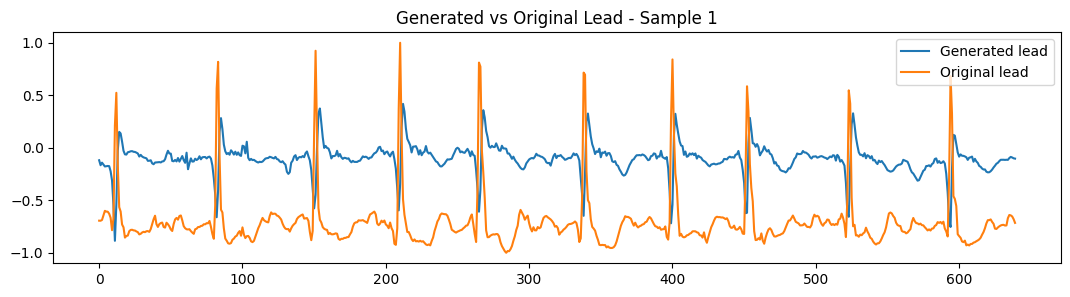

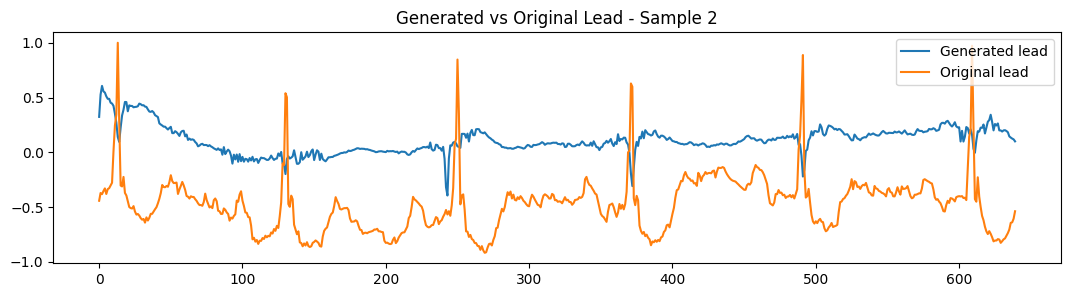

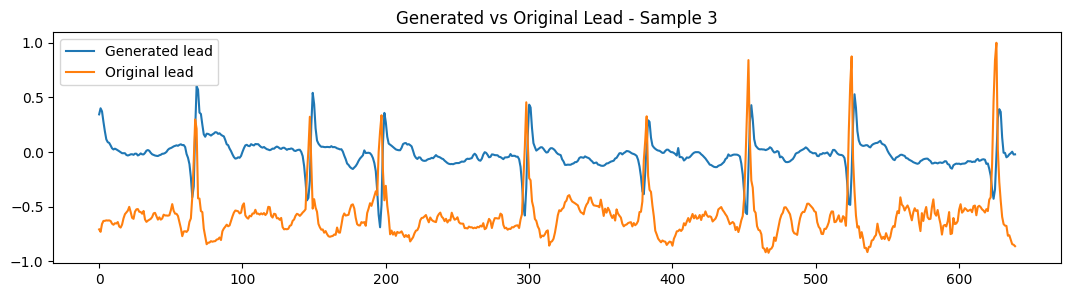

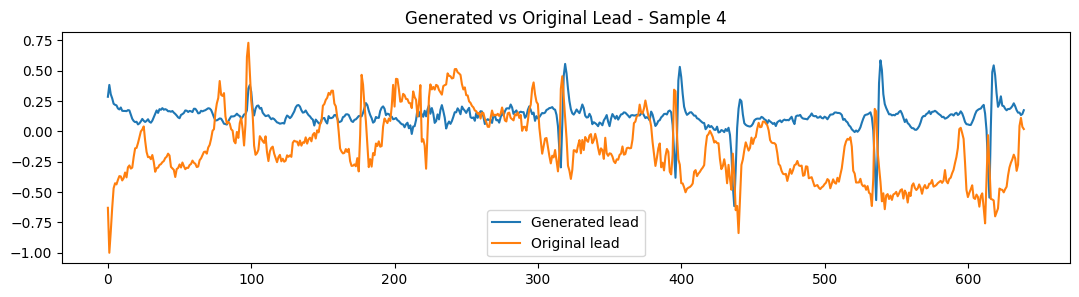

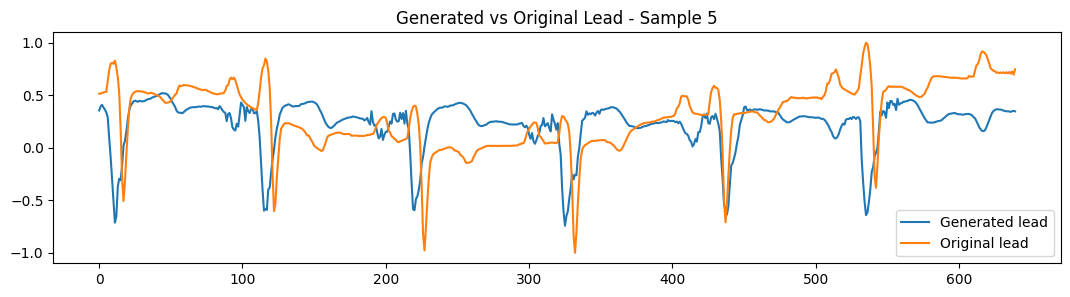

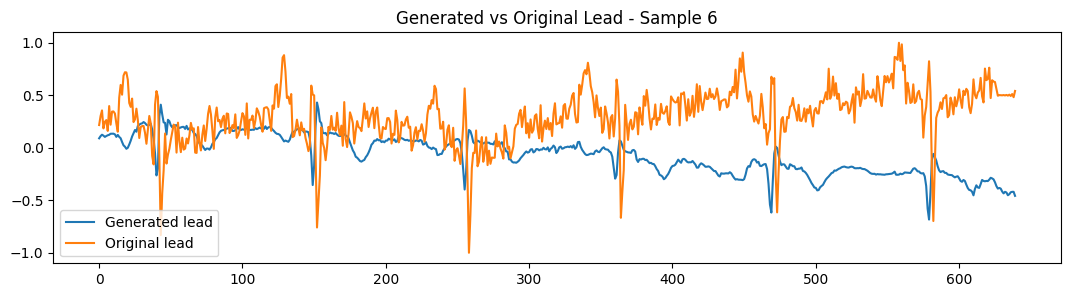

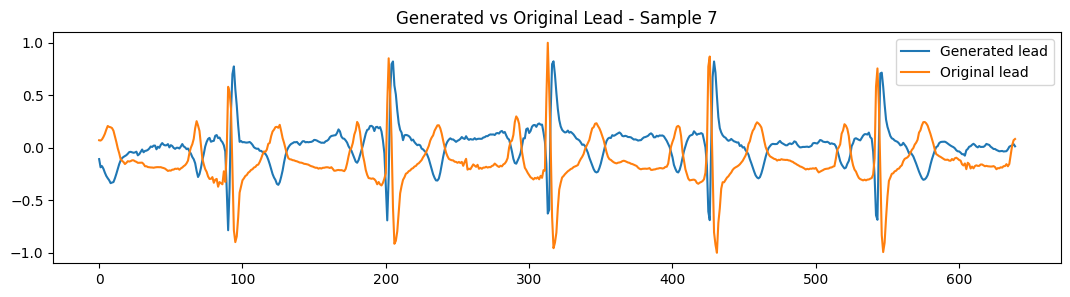

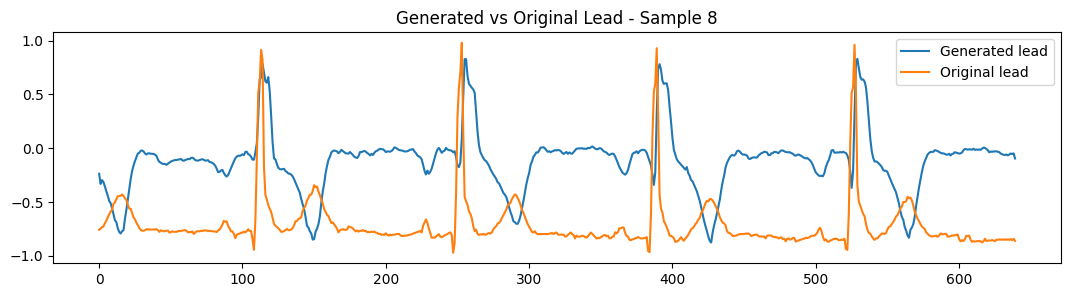

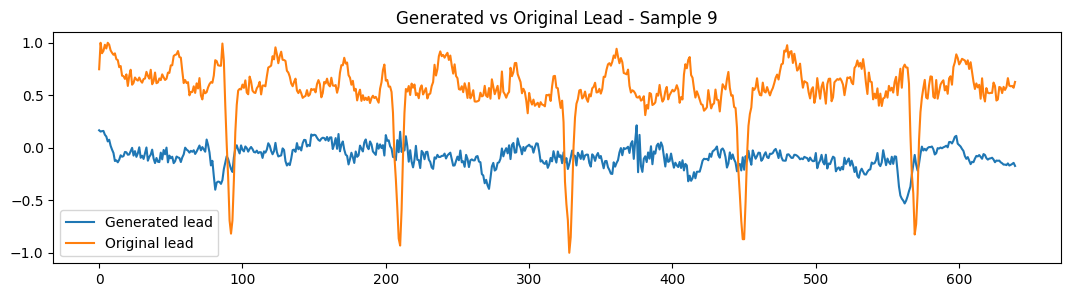

In [19]:
import matplotlib.pyplot as plt
for i in range(1, 10):
    plt.figure(figsize=(13, 3))
    plt.plot(fake_ecgs[i], label='Generated lead')
    plt.plot(real_ecg2[i], label='Original lead')
    plt.title(f'Generated vs Original Lead - Sample {i}')
    plt.legend()
    plt.show()

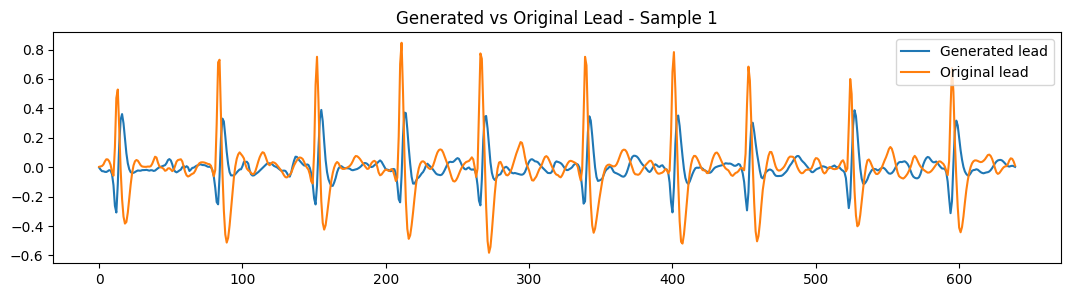

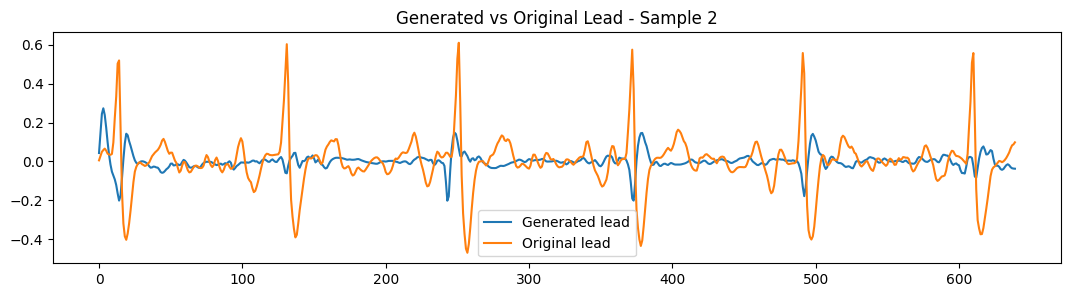

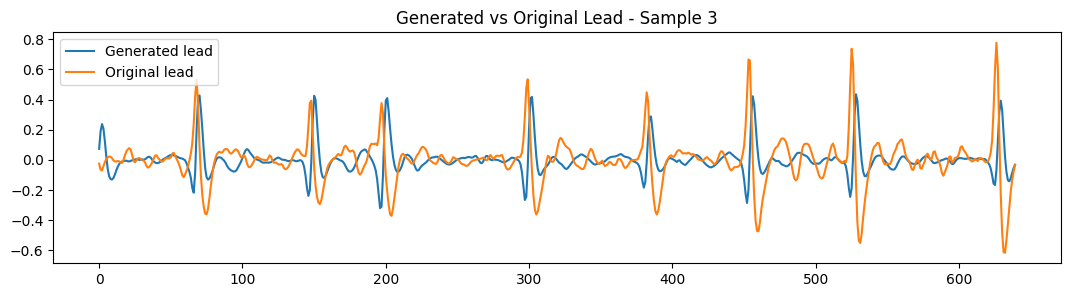

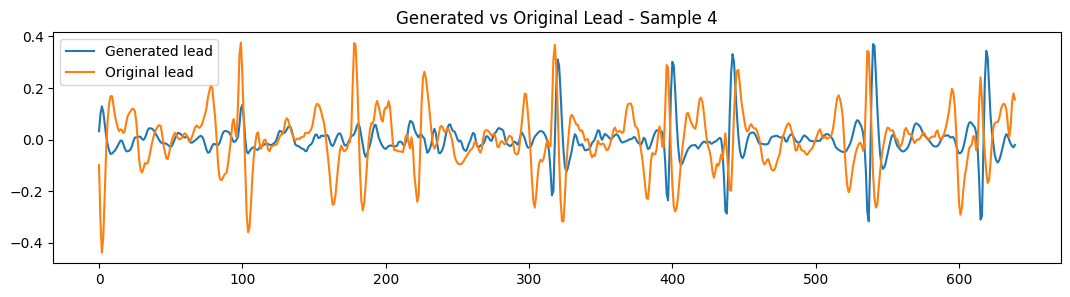

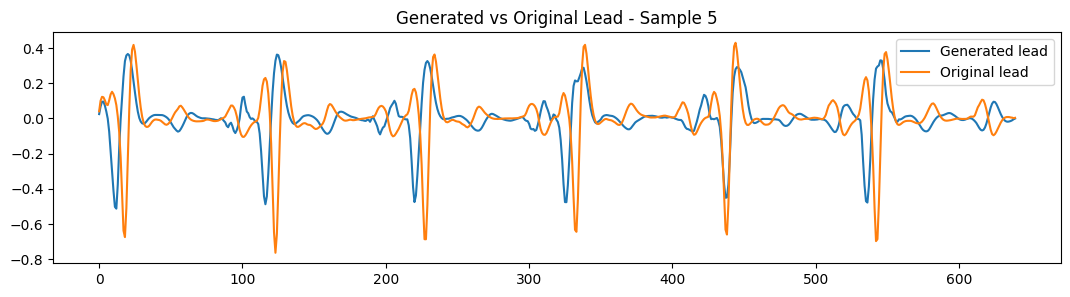

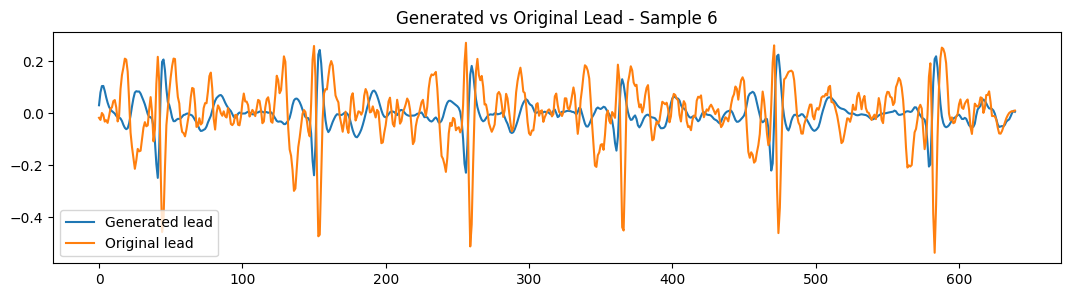

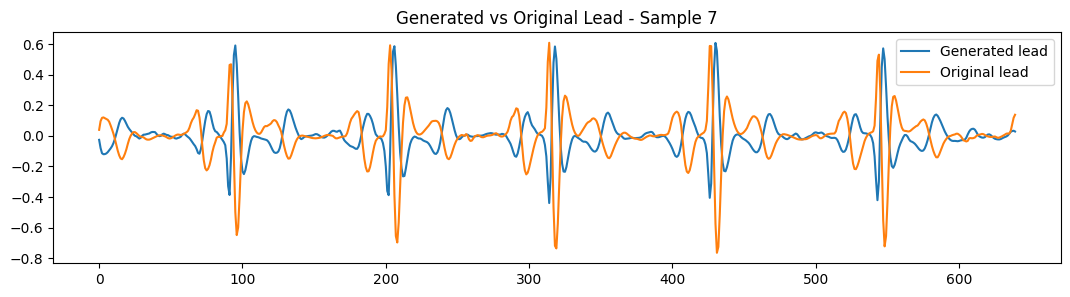

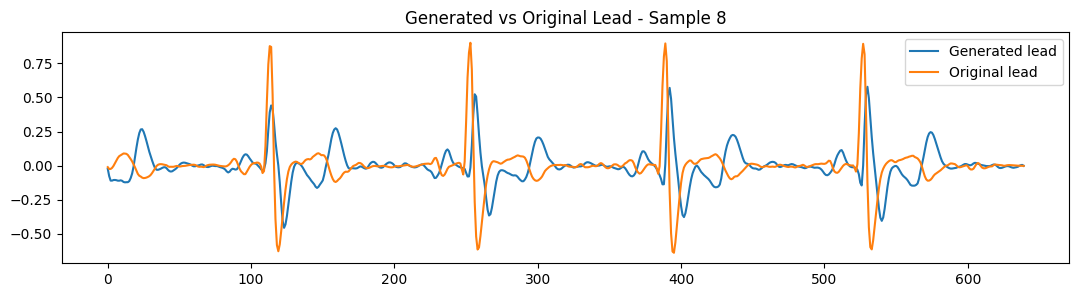

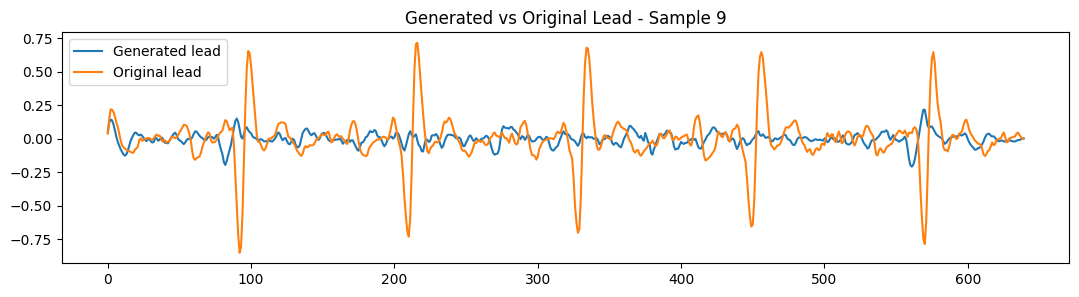

In [20]:
import matplotlib.pyplot as plt
import neurokit2 as nk
for i in range(1, 10):
    plt.figure(figsize=(13, 3))
    plt.plot(nk.ecg_clean(fake_ecgs[i], sampling_rate=128, method="pantompkins1985"), label='Generated lead')
    plt.plot(nk.ecg_clean(real_ecg2[i], sampling_rate=128, method="pantompkins1985") , label='Original lead')
    plt.title(f'Generated vs Original Lead - Sample {i}')
    plt.legend()
    plt.show()

In [21]:
for dataset_name in ["PTBXL"]:     
    fake_ecgs, real_ecg2, real_ecg1 = eval_diffusion(
        window_size=5,
        EVAL_DATASETS=[dataset_name],
        nT=10,
        PATH="/tf/hsh/SW_ECG/RDDM_ECG/finalmodel/fftloss/1to4/",
        check_sig=True
    )

  0%|          | 0/266 [00:03<?, ?it/s]


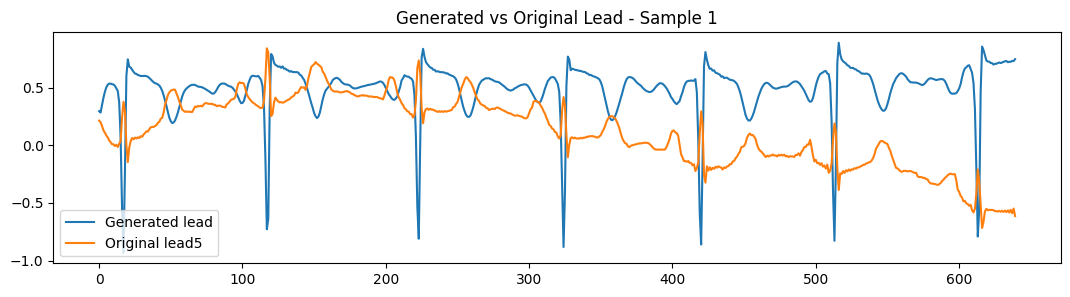

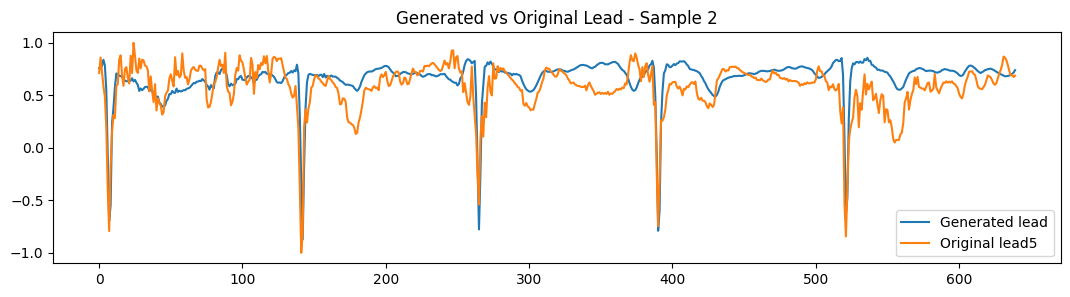

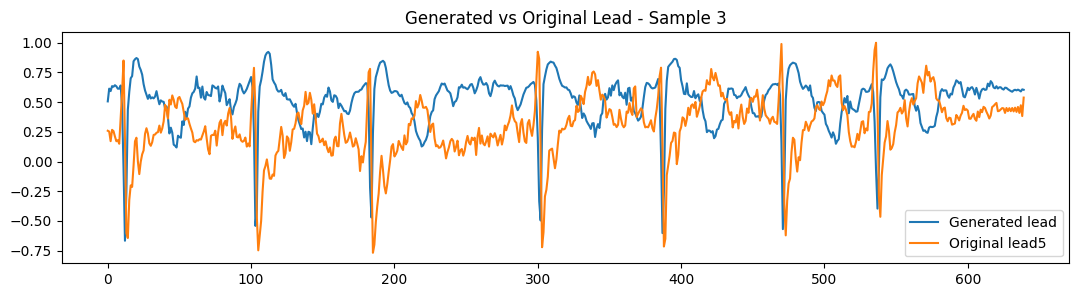

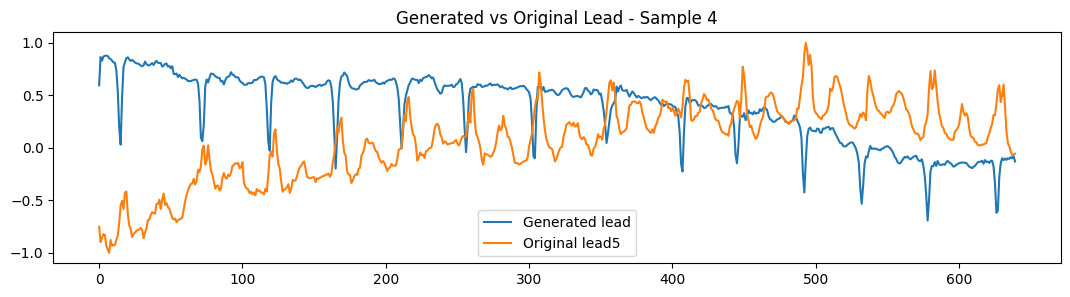

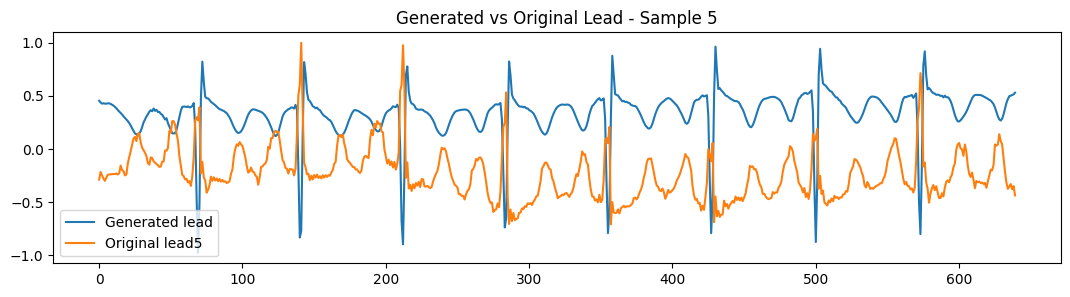

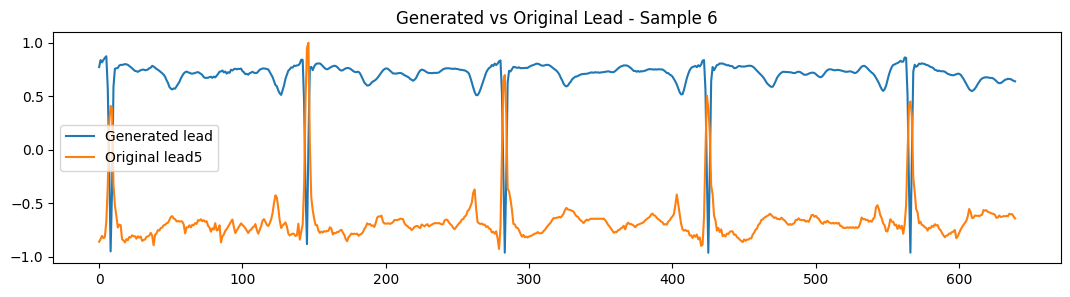

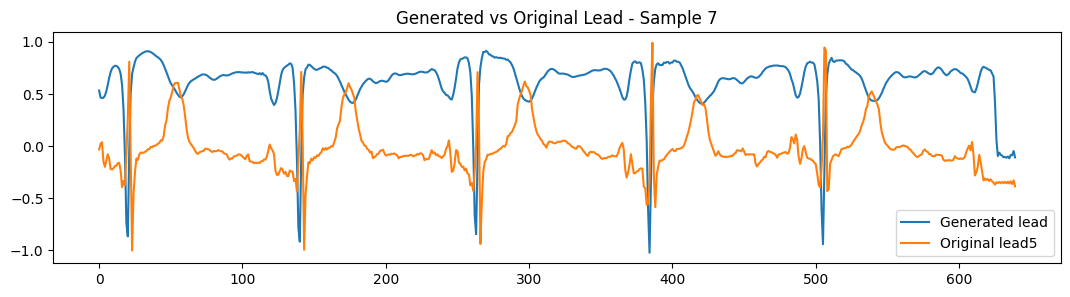

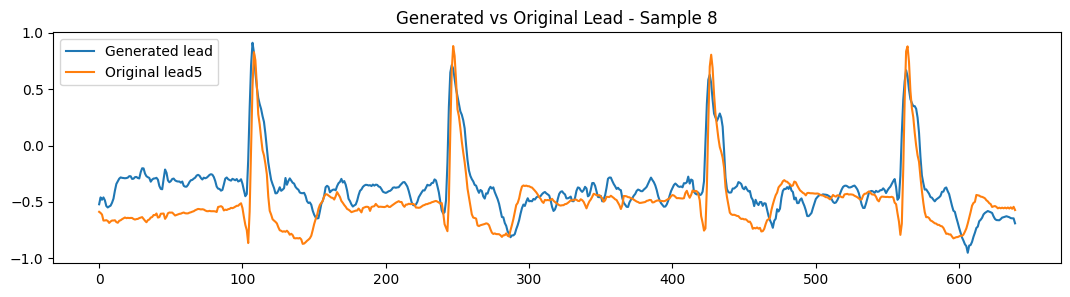

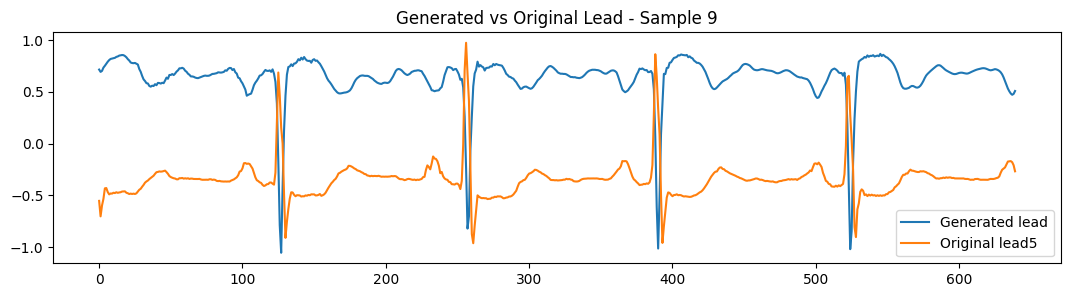

In [22]:
import matplotlib.pyplot as plt

for i in range(1, 10):
    plt.figure(figsize=(13, 3))
    plt.plot(fake_ecgs[i], label='Generated lead')
    plt.plot(real_ecg2[i], label='Original lead5')
    plt.title(f'Generated vs Original Lead - Sample {i}')
    plt.legend()
    plt.show()

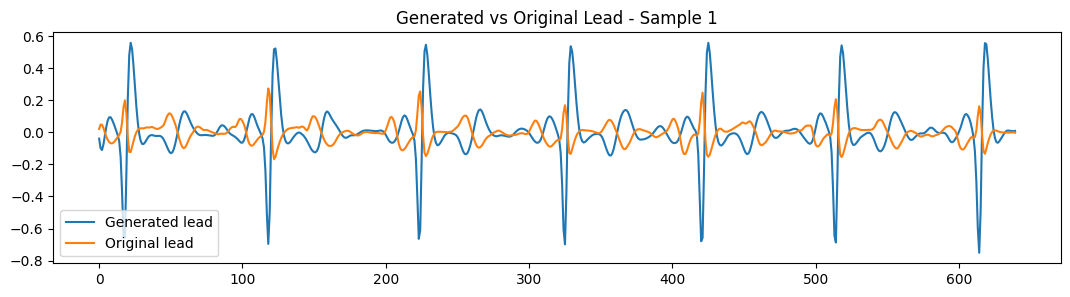

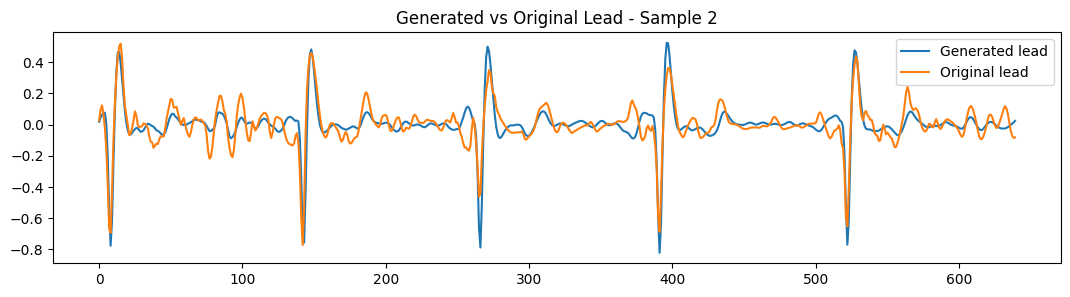

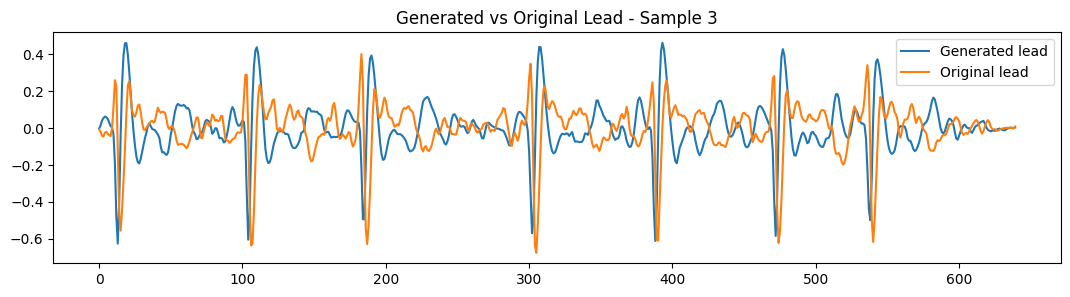

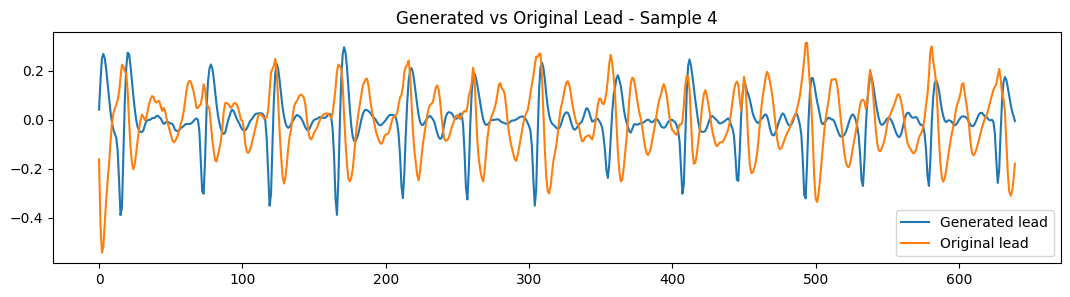

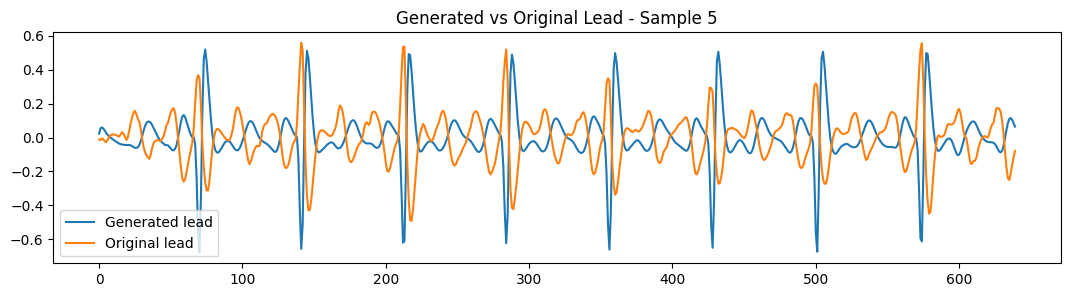

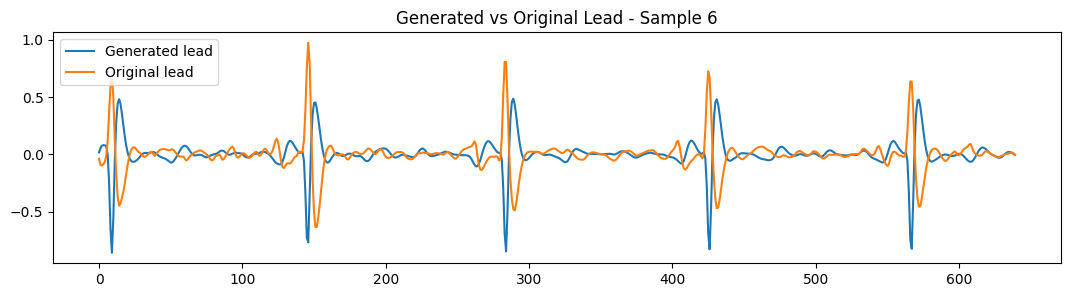

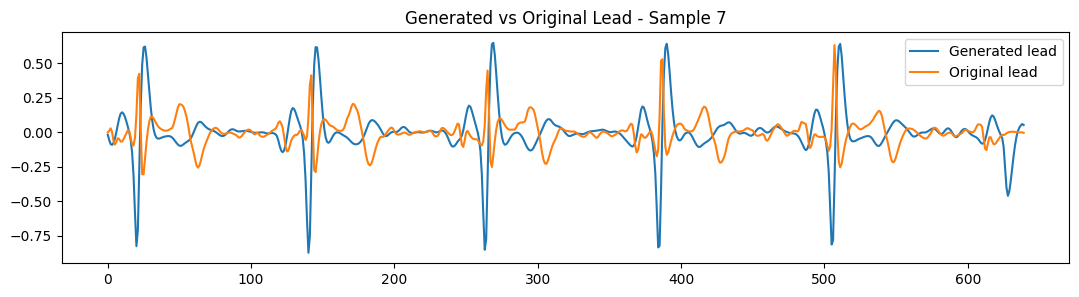

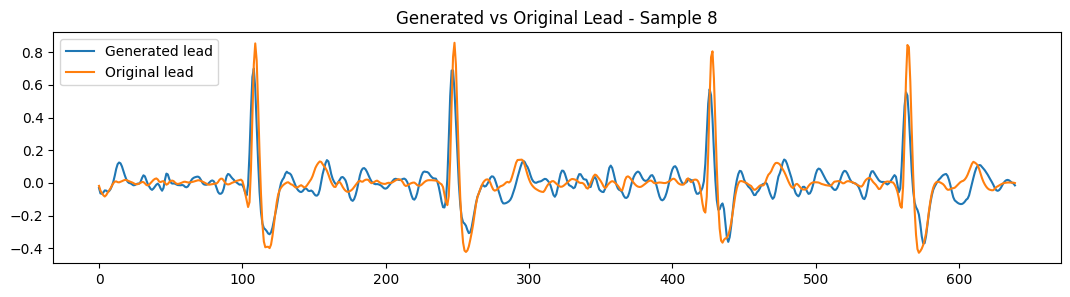

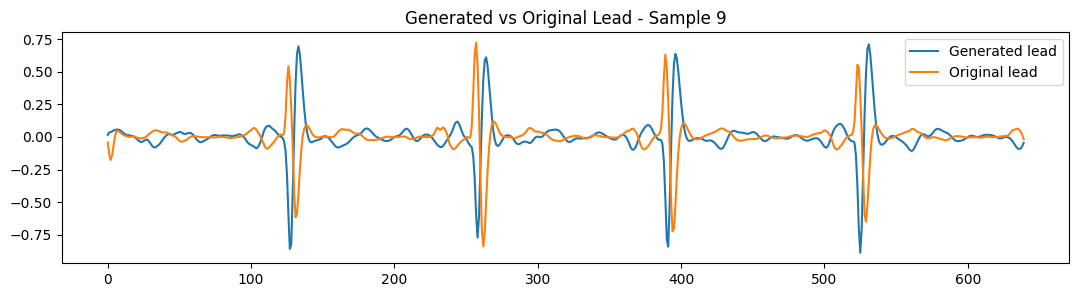

In [23]:
import matplotlib.pyplot as plt
import neurokit2 as nk
for i in range(1, 10):
    plt.figure(figsize=(13, 3))
    plt.plot(nk.ecg_clean(fake_ecgs[i], sampling_rate=128, method="pantompkins1985"), label='Generated lead')
    plt.plot(nk.ecg_clean(real_ecg2[i], sampling_rate=128, method="pantompkins1985") , label='Original lead')
    plt.title(f'Generated vs Original Lead - Sample {i}')
    plt.legend()
    plt.show()